In [ ]:
!pip install numpy matplotlib torch

In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
import torch.nn as nn

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()

        # This is a simple Feedforward Neural Network (MLP)
        # used to approximate Q-values: Q(s, a)

        self.net = nn.Sequential(
            # First layer:
            # Takes state input (input_dim) → maps to 64 neurons
            nn.Linear(input_dim, 64),

            # Activation function (non-linearity)
            # Helps model learn complex patterns
            nn.ReLU(),

            # Hidden layer:
            # 64 → 64 neurons (feature extraction continues)
            nn.Linear(64, 64),
            nn.ReLU(),

            # Output layer:
            # Produces Q-values for each action
            # output_dim = number of possible actions
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        # Forward pass:
        # Input state → Q-values for all actions
        return self.net(x)

In [ ]:
from collections import deque
import random
import numpy as np

class ReplayBuffer:
    def __init__(self, capacity=10000):
        # deque = double-ended queue
        # maxlen ensures old experiences are automatically removed (FIFO)
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        # Store one experience (transition)
        # (s, a, r, s')
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        # Randomly sample a batch of experiences
        # Breaks correlation between sequential data (VERY important for DQN)
        batch = random.sample(self.buffer, batch_size)

        # Unzip batch into separate components
        states, actions, rewards, next_states = zip(*batch)

        # Convert to numpy arrays for model input
        return np.array(states), actions, rewards, np.array(next_states)

    def __len__(self):
        # Returns current size of buffer
        return len(self.buffer)

In [ ]:
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        # Main Q-network → learns Q(s, a)
        self.model = DQN(state_dim, action_dim)

        # Target network → used to stabilize training (fixed for some steps)
        self.target_model = DQN(state_dim, action_dim)

        # Initialize target network with same weights as main network
        self.target_model.load_state_dict(self.model.state_dict())

        # Optimizer → updates model weights using gradients
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)

        # Replay buffer → stores past experiences (s, a, r, s')
        self.memory = ReplayBuffer()

        # Discount factor → importance of future rewards
        self.gamma = 0.95

        # Epsilon-greedy parameters → controls exploration vs exploitation
        self.epsilon = 1.0          # start with full exploration
        self.epsilon_decay = 0.995  # gradually reduce exploration
        self.epsilon_min = 0.05     # minimum exploration level

        # Number of possible actions
        self.action_dim = action_dim

    def select_action(self, state):
        # With probability epsilon → choose random action (exploration)
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        # Otherwise → choose best action from model (exploitation)
        state = torch.FloatTensor(state)

        # Disable gradient calculation during inference
        with torch.no_grad():
            q_values = self.model(state)

        # Return action with highest Q-value
        return torch.argmax(q_values).item()

    def train(self, batch_size=32):
        # Do not train until enough samples are available
        if len(self.memory) < batch_size:
            return

        # Sample random batch from replay buffer
        states, actions, rewards, next_states = self.memory.sample(batch_size)

        # Convert data into tensors for neural network
        states = torch.FloatTensor(states)
        next_states = torch.FloatTensor(next_states)
        rewards = torch.FloatTensor(rewards)
        actions = torch.LongTensor(actions)

        # Compute Q-values for current states → Q(s, a)
        q_values = self.model(states)

        # Compute Q-values for next states using target network → Q(s', a')
        next_q_values = self.target_model(next_states)

        # Select Q-values corresponding to actions taken
        # gather picks Q(s,a) for each sample in batch
        q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()

        # Get maximum Q-value for next states (best possible future action)
        next_q_value = torch.max(next_q_values, dim=1)[0]

        # Bellman equation:
        # target = reward + gamma * max Q(s', a')
        target = rewards + self.gamma * next_q_value

        # Loss between predicted Q and target Q
        # MSE measures how far predictions are from target
        loss = nn.MSELoss()(q_value, target.detach())

        # Backpropagation step
        self.optimizer.zero_grad()  # clear previous gradients
        loss.backward()             # compute gradients
        self.optimizer.step()       # update weights

        # Reduce epsilon → gradually shift from exploration → exploitation
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target(self):
        # Copy weights from main model → target model
        # This helps stabilize learning
        self.target_model.load_state_dict(self.model.state_dict())

In [ ]:
class Country:
    def __init__(self, name, power):
        # Name of the country (e.g., "India", "USA")
        self.name = name

        # Power level of the country → could represent influence, economy, military strength, etc.
        self.power = power

        # -------- Ethical vectors --------
        # Each is a 3D vector representing priorities/behavior in decision-making

        # Government perspective → policies, regulations, national interest
        self.gov = np.random.rand(3)

        # Company perspective → profit, innovation, market-driven ethics
        self.company = np.random.rand(3)

        # NGO perspective → social welfare, environment, humanitarian concerns
        self.ngo = np.random.rand(3)

In [ ]:
def distance(a, b):
    # Computes the Euclidean distance between two vectors a and b

    # (a - b) → element-wise difference between the two vectors
    # np.linalg.norm(...) → computes magnitude (length) of the resulting vector

    # Formula:
    # distance = sqrt( (a1-b1)^2 + (a2-b2)^2 + ... )

    return np.linalg.norm(a - b)

In [ ]:
def satisfaction(E, P):
    # Computes how "satisfied" or aligned two vectors are

    # E → Expected / desired ethical vector (what an agent wants)
    # P → Proposed / actual vector (what is offered/decided)

    # distance(E, P) → measures how far apart the two vectors are
    # Larger distance = more disagreement
    # Smaller distance = more agreement

    # 1 - distance → converts distance into a satisfaction score
    # So:
    # distance ≈ 0  → satisfaction ≈ 1 (high satisfaction)
    # distance large → satisfaction decreases

    return 1 - distance(E, P)

In [ ]:
def evaluate_country(country, P):
    # -------- Satisfaction of each internal stakeholder --------
    # Compare proposed policy P with each stakeholder's preference vector

    s_gov = satisfaction(country.gov, P)        # Government satisfaction
    s_comp = satisfaction(country.company, P)   # Company satisfaction
    s_ngo = satisfaction(country.ngo, P)        # NGO satisfaction

    # -------- Weighted overall satisfaction --------
    # Government and companies are given higher importance (0.4 each)
    # NGOs have slightly lower influence (0.2)

    S_country = 0.4*s_gov + 0.4*s_comp + 0.2*s_ngo

    # -------- Internal conflict calculation --------
    # Measure disagreement between stakeholders

    d1 = distance(country.gov, country.company)   # Gov vs Company
    d2 = distance(country.gov, country.ngo)       # Gov vs NGO
    d3 = distance(country.company, country.ngo)   # Company vs NGO

    # Average conflict across all pairs
    conflict = (d1 + d2 + d3) / 3

    # -------- Stability score --------
    # Higher conflict → lower stability
    # Formula ensures stability is always between (0, 1]

    stability = 1 / (1 + conflict)

    # -------- Final country index --------
    # Combines:
    # - Satisfaction (how happy stakeholders are)
    # - Stability (how aligned they are internally)

    I = 0.6 * S_country + 0.4 * stability

    # Return both overall index and stability separately
    return I, stability

In [ ]:
# -------- Create multiple countries --------
# Each country has:
# - name
# - power level (influence in global decisions)
# - internal stakeholders (gov, company, ngo → defined earlier)

countries = [
    Country("A", 0.9),  # Strong country (high influence)
    Country("B", 0.7),
    Country("C", 0.8),
    Country("D", 0.6)   # Relatively weaker influence
]

# -------- Shared DQN agents for sub-agents --------
# These represent decision-makers inside EACH country

# State dimension = 6
# (3 values from policy P + 3 values from agent's ethical vector)
state_dim = 6

# Action space:
# 0 → accept policy
# 1 → reject policy
# 2 → adjust policy
action_dim = 3

# Government agent → focuses on policy/regulation decisions
gov_agent = DQNAgent(state_dim, action_dim)

# Company agent → focuses on profit/business alignment
comp_agent = DQNAgent(state_dim, action_dim)

# NGO agent → focuses on social/environmental impact
ngo_agent = DQNAgent(state_dim, action_dim)

# -------- Country-level agent --------
# This agent makes higher-level decisions based on:
# - overall satisfaction
# - stability

# State dimension = 2
# [S_country, stability] → summarized internal condition

# Action space = 3 (same idea: accept / reject / adjust global policy)
country_agent = DQNAgent(2, 3)

In [ ]:
episodes = 200
results = []

# -------- Main training loop over episodes --------
# Each episode = one simulation of global policy evaluation

for ep in range(episodes):

    # Generate a random global policy vector P (3D)
    # Represents proposed decision (e.g., economic, environmental, social factors)
    P = np.random.rand(3)

    total_score = 0  # aggregate global score for this episode

    # -------- Iterate over all countries --------
    for c in countries:

        # -------- Internal decision-making (sub-agents) --------
        # Each stakeholder (gov, company, NGO) reacts to policy P

        for agent_type in ["gov", "company", "ngo"]:

            # Get stakeholder's ethical preference vector
            E = getattr(c, agent_type)

            # State = [policy P + stakeholder preference E]
            # → input for DQN agent
            state = np.concatenate([P, E])

            # Select corresponding agent
            if agent_type == "gov":
                agent = gov_agent
            elif agent_type == "company":
                agent = comp_agent
            else:
                agent = ngo_agent

            # Choose action using epsilon-greedy policy
            action = agent.select_action(state)

            # -------- Action effects --------
            # 0 → accept (no change)
            # 1 → reject (no direct change here, but could be extended)
            # 2 → adjust (move E slightly toward policy P)

            if action == 2:  # adjust
                # Move stakeholder preference closer to policy
                E = E + 0.1 * (P - E)

            # Update stakeholder vector in the country
            setattr(c, agent_type, E)

            # -------- Reward calculation --------
            # Negative distance → closer to policy = higher reward
            reward = -distance(E, P)

            # Next state after action
            next_state = np.concatenate([P, E])

            # Store experience in replay buffer
            agent.memory.push(state, action, reward, next_state)

            # Train agent using sampled experiences
            agent.train()

        # -------- Country-level evaluation --------
        # Combines satisfaction + stability into index I
        I, stability = evaluate_country(c, P)

        # Weighted by country power (stronger countries influence more)
        total_score += c.power * I

    # Store total global score for this episode
    results.append(total_score)

    # -------- Target network update --------
    # Done periodically to stabilize DQN training
    if ep % 10 == 0:
        gov_agent.update_target()
        comp_agent.update_target()
        ngo_agent.update_target()

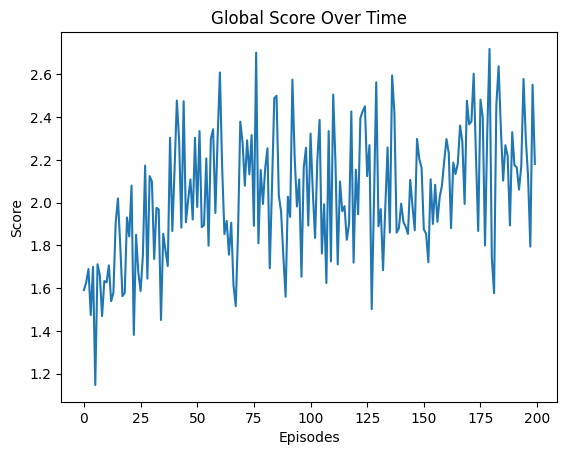

In [ ]:
plt.plot(results)
# Plots the global score for each episode
# X-axis → episode number (training progression)
# Y-axis → total_score (overall performance of all countries)

plt.title("Global Score Over Time")
# Title of the graph → shows what is being tracked

plt.xlabel("Episodes")
# X-axis label → number of training iterations

plt.ylabel("Score")
# Y-axis label → aggregated global score (power-weighted country index)

plt.show()
# Displays the plot

In [ ]:
!pip install numpy matplotlib torch

In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()

        # -------- Neural Network Architecture --------
        # This is a simple Feedforward Neural Network (MLP)
        # used to approximate the Q-function: Q(s, a)

        self.net = nn.Sequential(
            # Input layer:
            # Takes state vector of size = input_dim
            # Outputs 64 features (hidden representation)
            nn.Linear(input_dim, 64),

            # Activation function:
            # Introduces non-linearity so the network can learn complex patterns
            nn.ReLU(),

            # Hidden layer:
            # Further transforms features (64 → 64)
            nn.Linear(64, 64),
            nn.ReLU(),

            # Output layer:
            # Produces Q-values for each possible action
            # output_dim = number of actions
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        # Forward pass:
        # Input state → passes through network → outputs Q-values
        return self.net(x)

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        # deque = double-ended queue
        # maxlen ensures that once capacity is reached,
        # the oldest experiences are automatically removed (FIFO behavior)
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        # Store a single experience (transition)
        # (state, action, reward, next_state)
        # This represents: s → a → r → s'
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        # Randomly sample a batch of experiences from memory
        # This breaks temporal correlation between consecutive samples
        batch = random.sample(self.buffer, batch_size)

        # Unzip the batch into separate components
        states, actions, rewards, next_states = zip(*batch)

        # Convert states and next_states into numpy arrays
        # (better format for neural network input)
        return np.array(states), actions, rewards, np.array(next_states)

    def __len__(self):
        # Returns current number of stored experiences
        # Used to check if enough data is available for training
        return len(self.buffer)

In [ ]:
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        # -------- Main Q-Network --------
        # Learns the Q-function: Q(s, a)
        self.model = DQN(state_dim, action_dim)

        # -------- Target Network --------
        # Used to stabilize training by keeping a fixed reference
        self.target_model = DQN(state_dim, action_dim)

        # Copy weights from main model → target model initially
        self.target_model.load_state_dict(self.model.state_dict())

        # -------- Optimizer --------
        # Adam optimizer updates neural network weights using gradients
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)

        # -------- Replay Buffer --------
        # Stores past experiences for training
        self.memory = ReplayBuffer()

        # -------- Hyperparameters --------
        self.gamma = 0.95          # Discount factor (future reward importance)

        # Epsilon-greedy strategy for exploration vs exploitation
        self.epsilon = 1.0         # Start fully random (exploration)
        self.epsilon_decay = 0.995 # Gradually reduce exploration
        self.epsilon_min = 0.05    # Minimum exploration

        # Number of possible actions
        self.action_dim = action_dim

    def select_action(self, state):
        # -------- Epsilon-Greedy Policy --------
        # With probability epsilon → explore (random action)
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        # Otherwise → exploit (choose best action from model)
        state = torch.FloatTensor(state)

        # Disable gradient tracking for inference
        with torch.no_grad():
            q_values = self.model(state)

        # Return action with highest Q-value
        return torch.argmax(q_values).item()

    def train(self, batch_size=32):
        # Do not train until enough experiences are available
        if len(self.memory) < batch_size:
            return

        # -------- Sample batch from replay buffer --------
        states, actions, rewards, next_states = self.memory.sample(batch_size)

        # Convert data into tensors for neural network processing
        states = torch.FloatTensor(states)
        next_states = torch.FloatTensor(next_states)
        rewards = torch.FloatTensor(rewards)
        actions = torch.LongTensor(actions)

        # -------- Compute Q-values --------
        # Q(s, a) from main network
        q_values = self.model(states)

        # Q(s', a') from target network
        next_q_values = self.target_model(next_states)

        # Extract Q-values corresponding to actions taken
        # gather selects Q(s,a) for each sample in batch
        q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()

        # Get maximum Q-value for next states (best future action)
        next_q_value = torch.max(next_q_values, dim=1)[0]

        # -------- Bellman Equation --------
        # target = reward + gamma * max Q(s', a')
        target = rewards + self.gamma * next_q_value

        # -------- Loss Calculation --------
        # MSE loss measures difference between predicted and target Q-values
        loss = nn.MSELoss()(q_value, target.detach())

        # -------- Backpropagation --------
        self.optimizer.zero_grad()  # Clear old gradients
        loss.backward()             # Compute new gradients
        self.optimizer.step()       # Update model weights

        # -------- Epsilon Decay --------
        # Reduce exploration over time
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target(self):
        # -------- Target Network Update --------
        # Copy weights from main model → target model
        # Helps stabilize training by reducing oscillations
        self.target_model.load_state_dict(self.model.state_dict())

In [ ]:
class Country:
    def __init__(self, name, power):
        # Name of the country (identifier)
        self.name = name

        # Power of the country → represents influence in global decision-making
        # Could model economic strength, political influence, etc.
        self.power = power

        # -------- Internal stakeholder preference vectors --------
        # Each is a 3-dimensional vector representing priorities/ethics

        # Government perspective → policies, regulation, national interest
        self.gov = np.random.rand(3)

        # Company perspective → profit, growth, market-driven behavior
        self.company = np.random.rand(3)

        # NGO perspective → social welfare, environment, humanitarian concerns
        self.ngo = np.random.rand(3)

In [ ]:
def distance(a, b):
    # -------- Euclidean Distance --------
    # Measures how far apart two vectors are in space

    # (a - b) → element-wise difference
    # np.linalg.norm → computes magnitude (√sum of squares)

    # Formula:
    # sqrt((a1-b1)^2 + (a2-b2)^2 + (a3-b3)^2)

    return np.linalg.norm(a - b)


def satisfaction(E, P):
    # -------- Satisfaction Function --------
    # Converts distance into an alignment score

    # E → stakeholder preference vector
    # P → proposed policy vector

    # Smaller distance → higher satisfaction
    # Larger distance → lower satisfaction

    # 1 - distance → transforms "difference" into "agreement score"
    return 1 - distance(E, P)


def evaluate_country(country, P):
    # -------- Step 1: Stakeholder Satisfaction --------
    # Measure how each internal agent feels about policy P

    s_gov = satisfaction(country.gov, P)        # Government satisfaction
    s_comp = satisfaction(country.company, P)   # Company satisfaction
    s_ngo = satisfaction(country.ngo, P)        # NGO satisfaction

    # -------- Step 2: Weighted Satisfaction --------
    # Combine all stakeholder satisfaction into a single score
    # Govt and company have higher influence than NGO

    S_country = 0.4*s_gov + 0.4*s_comp + 0.2*s_ngo

    # -------- Step 3: Internal Conflict --------
    # Measure disagreement between stakeholders

    d1 = distance(country.gov, country.company)   # Gov vs Company
    d2 = distance(country.gov, country.ngo)       # Gov vs NGO
    d3 = distance(country.company, country.ngo)   # Company vs NGO

    # Average disagreement → overall internal conflict
    conflict = (d1 + d2 + d3) / 3

    # -------- Step 4: Stability --------
    # Convert conflict into stability score
    # Higher conflict → lower stability

    stability = 1 / (1 + conflict)

    # -------- Step 5: Final Country Index --------
    # Combine satisfaction + stability

    I = 0.6 * S_country + 0.4 * stability

    # Return:
    # I → overall country performance
    # stability → internal alignment indicator
    return I, stability

In [ ]:
countries = [
    Country("A", 0.9),  # Country A with high power (strong influence)
    Country("B", 0.7),  # Medium-high influence
    Country("C", 0.8),  # Strong influence
    Country("D", 0.6)   # Relatively lower influence
]

# -------- State & Action Space Definition --------

# State dimension = 6
# [policy vector P (3 values) + stakeholder preference E (3 values)]
state_dim = 6

# Action dimension = 3
# 0 → accept policy
# 1 → reject policy
# 2 → adjust preference toward policy
action_dim = 3

# -------- Sub-agents (within each country) --------

# Government agent → focuses on regulation, policy alignment
gov_agent = DQNAgent(state_dim, action_dim)

# Company agent → focuses on profit/economic alignment
comp_agent = DQNAgent(state_dim, action_dim)

# NGO agent → focuses on social/environmental alignment
ngo_agent = DQNAgent(state_dim, action_dim)

# -------- Country-level agent --------

# State dimension = 2
# [S_country (overall satisfaction), stability (internal harmony)]

# Action space = 3 (same idea: accept / reject / adjust global stance)
country_agent = DQNAgent(2, 3)

In [ ]:
# -------- Metrics Tracking Lists --------

# Stores stability values over episodes
# Stability → how aligned internal stakeholders (gov, company, NGO) are
# Higher value = less internal conflict
stability_history = []

# Stores conflict values over episodes
# Conflict → average disagreement between stakeholders
# Higher value = more disagreement inside a country
conflict_history = []

# Stores distance values over episodes
# Distance → how far stakeholder preferences are from policy P
# Used to measure alignment with proposed policy
distance_history = []

In [ ]:
episodes = 200
results = []
acceptance_history = []  # Tracks whether global policy was accepted (1) or not (0)

for ep in range(episodes):

    # -------- Generate random global policy --------
    P = np.random.rand(3)

    country_scores = []   # Stores country index (I) for each country
    country_actions = []  # Stores final action of each country agent

    # -------- Sub-agent learning (inside each country) --------
    for c in countries:

        # Each stakeholder (gov, company, NGO) reacts to policy
        for agent_type in ["gov", "company", "ngo"]:

            # Get stakeholder preference vector
            E = getattr(c, agent_type)

            # State = policy + stakeholder preference
            state = np.concatenate([P, E])

            # Select correct agent
            agent = gov_agent if agent_type=="gov" else comp_agent if agent_type=="company" else ngo_agent

            # Choose action using epsilon-greedy
            action = agent.select_action(state)

            # -------- Action effect --------
            # Only "adjust" modifies stakeholder preference
            if action == 2:
                # Move preference slightly toward policy (negotiation step)
                E = E + 0.1*(P - E)

            # Update stakeholder vector
            setattr(c, agent_type, E)

            # -------- Reward --------
            # Closer to policy → higher reward
            reward = -distance(E, P)

            # Next state after action
            next_state = np.concatenate([P, E])

            # Store experience and train
            agent.memory.push(state, action, reward, next_state)
            agent.train()

        # -------- Country evaluation --------
        I, stability = evaluate_country(c, P)

        # -------- Conflict calculation --------
        # Measure internal disagreement between stakeholders
        d1 = distance(c.gov, c.company)
        d2 = distance(c.gov, c.ngo)
        d3 = distance(c.company, c.ngo)

        conflict = (d1 + d2 + d3) / 3

        # -------- Ethical distance --------
        # Measures how far stakeholders are from policy
        dist = (distance(c.gov, P) + distance(c.company, P) + distance(c.ngo, P)) / 3

        # Store country score
        country_scores.append(I)

        # -------- Store global metrics --------
        stability_history.append(stability)
        conflict_history.append(conflict)
        distance_history.append(dist)

    # -------- Country-level decisions --------
    for i, c in enumerate(countries):
        # State = [country performance, country power]
        state = np.array([country_scores[i], c.power])

        # Country decides: accept / reject / adjust
        action = country_agent.select_action(state)
        country_actions.append(action)

    # -------- Coalition bonus --------
    # If countries have similar scores → they align → bonus
    coalition_bonus = 0
    for i in range(len(countries)):
        for j in range(i+1, len(countries)):
            # If countries are similar → increase cooperation score
            if abs(country_scores[i] - country_scores[j]) < 0.1:
                coalition_bonus += 0.1

    # -------- Global decision aggregation --------
    total_score = 0
    for i, c in enumerate(countries):
        action = country_actions[i]
        I = country_scores[i]

        # 0 → accept → positive contribution
        if action == 0:
            total_score += c.power * I

        # 1 → reject → negative contribution
        elif action == 1:
            total_score -= c.power * I

        # 2 → adjust → positive + coalition effect
        else:
            total_score += c.power * I + coalition_bonus

    # -------- Final acceptance decision --------
    accepted = total_score > 1.5  # threshold for global agreement

    # Store acceptance history
    acceptance_history.append(1 if accepted else 0)

    # Store total score
    results.append(total_score)

    # -------- Country-level learning --------
    for i, c in enumerate(countries):
        state = np.array([country_scores[i], c.power])

        # Reward depends on global outcome
        reward = total_score if accepted else -1

        # Store experience for country agent
        country_agent.memory.push(state, country_actions[i], reward, state)

        # Train country-level agent
        country_agent.train()

    # -------- Target network updates --------
    # Periodically sync weights to stabilize training
    if ep % 10 == 0:
        gov_agent.update_target()
        comp_agent.update_target()
        ngo_agent.update_target()
        country_agent.update_target()

In [ ]:
def smooth(data, window=20):
    return [np.mean(data[max(0,i-window):i+1]) for i in range(len(data))]

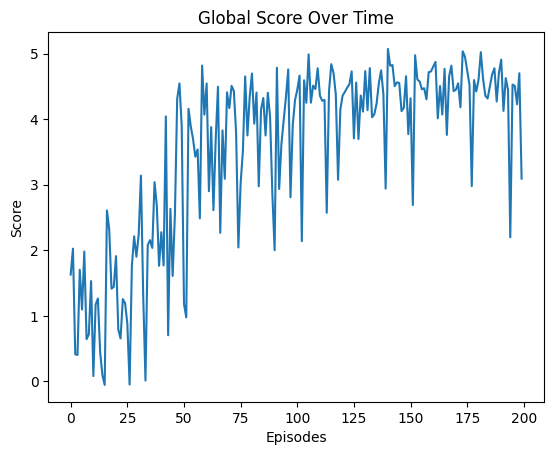

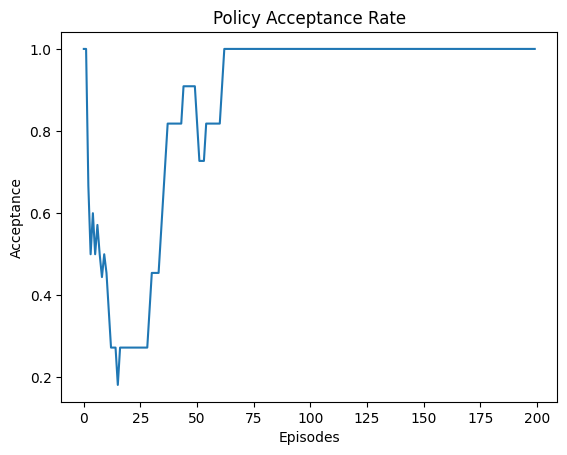

In [ ]:
plt.plot(results)
plt.title("Global Score Over Time")
plt.xlabel("Episodes")
plt.ylabel("Score")
plt.show()

window = 10
avg_acceptance = [np.mean(acceptance_history[max(0,i-window):i+1]) for i in range(len(acceptance_history))]

plt.plot(avg_acceptance)
plt.title("Policy Acceptance Rate")
plt.xlabel("Episodes")
plt.ylabel("Acceptance")
plt.show()

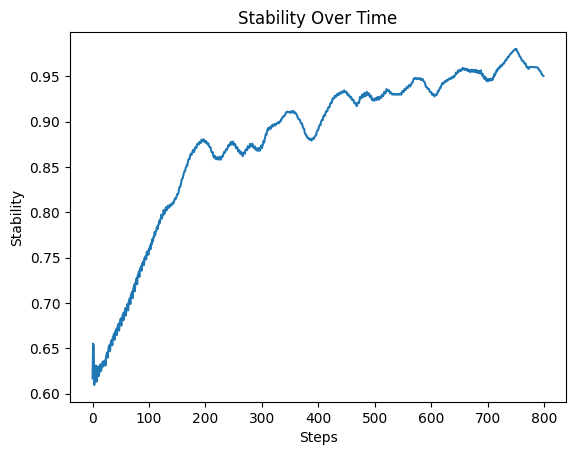

In [ ]:
plt.plot(smooth(stability_history))
plt.title("Stability Over Time")
plt.xlabel("Steps")
plt.ylabel("Stability")
plt.show()

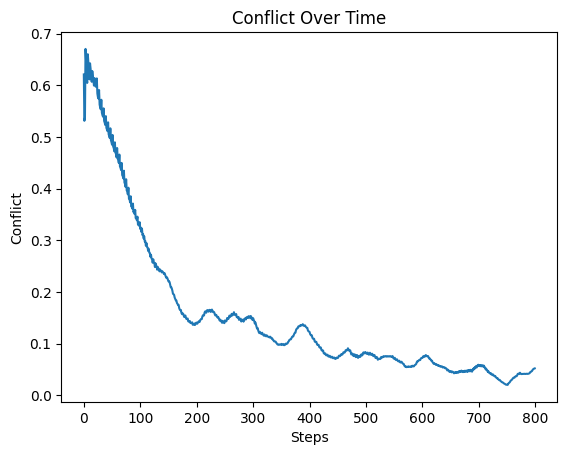

In [ ]:
plt.plot(smooth(conflict_history))
plt.title("Conflict Over Time")
plt.xlabel("Steps")
plt.ylabel("Conflict")
plt.show()

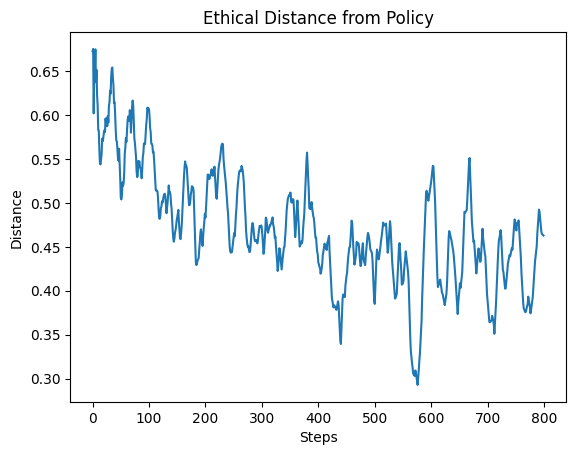

In [ ]:
plt.plot(smooth(distance_history))
plt.title("Ethical Distance from Policy")
plt.xlabel("Steps")
plt.ylabel("Distance")
plt.show()

In [ ]:
!pip install numpy matplotlib torch

In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()

        # -------- Neural Network Definition --------
        # This network approximates the Q-function: Q(s, a)
        # Input → state vector
        # Output → Q-values for each possible action

        self.net = nn.Sequential(
            # First layer:
            # Maps input state (size = input_dim) to 64 hidden neurons
            nn.Linear(input_dim, 64),

            # Activation function:
            # Adds non-linearity so the network can learn complex relationships
            nn.ReLU(),

            # Second hidden layer:
            # Further transforms features (64 → 64)
            nn.Linear(64, 64),
            nn.ReLU(),

            # Output layer:
            # Produces Q-values for each action (size = output_dim)
            # No activation → Q-values can be any real number
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        # -------- Forward Pass --------
        # Takes input state x and passes through network
        # Returns Q-values for all possible actions
        return self.net(x)

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        # deque = efficient queue for adding/removing elements
        # maxlen ensures buffer does not exceed capacity
        # When full → oldest experiences are automatically removed (FIFO)
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        # Store a single experience (transition)
        # Format: (state, action, reward, next_state)
        # Represents one step of interaction: s → a → r → s'
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        # Randomly sample a batch of experiences
        # This breaks correlation between consecutive samples
        batch = random.sample(self.buffer, batch_size)

        # Unpack batch into separate components
        states, actions, rewards, next_states = zip(*batch)

        # Convert states and next_states to numpy arrays
        # (suitable for feeding into neural network)
        return np.array(states), actions, rewards, np.array(next_states)

    def __len__(self):
        # Returns number of stored experiences in buffer
        # Useful to check if enough samples exist before training
        return len(self.buffer)

In [ ]:
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        # -------- Main Q-Network --------
        # Learns Q(s, a) → expected future reward for each action
        self.model = DQN(state_dim, action_dim)

        # -------- Target Network --------
        # A stable copy of the model used for computing target Q-values
        self.target_model = DQN(state_dim, action_dim)

        # Initialize target network with same weights as main network
        self.target_model.load_state_dict(self.model.state_dict())

        # -------- Optimizer --------
        # Adam optimizer updates model weights during training
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)

        # -------- Replay Buffer --------
        # Stores past experiences for training (experience replay)
        self.memory = ReplayBuffer()

        # -------- Hyperparameters --------
        self.gamma = 0.95          # Discount factor (importance of future rewards)

        # Epsilon-greedy exploration strategy
        self.epsilon = 1.0         # Start with full exploration (random actions)
        self.epsilon_decay = 0.995 # Reduce exploration over time
        self.epsilon_min = 0.05    # Minimum exploration level

        # Number of possible actions
        self.action_dim = action_dim

    def select_action(self, state):
        # -------- Epsilon-Greedy Action Selection --------

        # With probability epsilon → choose random action (exploration)
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        # Otherwise → choose best action from model (exploitation)
        state = torch.FloatTensor(state)

        # Disable gradient tracking (inference only)
        with torch.no_grad():
            q_values = self.model(state)

        # Return index of action with highest Q-value
        return torch.argmax(q_values).item()

    def train(self, batch_size=32):
        # Do not train if not enough samples in memory
        if len(self.memory) < batch_size:
            return

        # -------- Sample experiences --------
        states, actions, rewards, next_states = self.memory.sample(batch_size)

        # Convert to tensors for neural network
        states = torch.FloatTensor(states)
        next_states = torch.FloatTensor(next_states)
        rewards = torch.FloatTensor(rewards)
        actions = torch.LongTensor(actions)

        # -------- Compute Q-values --------
        # Q(s, a) from main network
        q_values = self.model(states)

        # Q(s', a') from target network
        next_q_values = self.target_model(next_states)

        # Extract Q-values corresponding to actions actually taken
        # gather selects Q(s,a) for each sample in batch
        q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()

        # Get max Q-value for next state (best future action)
        next_q_value = torch.max(next_q_values, dim=1)[0]

        # -------- Bellman Equation --------
        # target = reward + gamma * max Q(s', a')
        target = rewards + self.gamma * next_q_value

        # -------- Loss Calculation --------
        # Mean Squared Error between predicted Q and target Q
        loss = nn.MSELoss()(q_value, target.detach())

        # -------- Backpropagation --------
        self.optimizer.zero_grad()  # Clear previous gradients
        loss.backward()             # Compute gradients
        self.optimizer.step()       # Update weights

        # -------- Epsilon Decay --------
        # Gradually shift from exploration → exploitation
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target(self):
        # -------- Target Network Update --------
        # Copy weights from main model → target model
        # Helps stabilize training and reduce oscillations
        self.target_model.load_state_dict(self.model.state_dict())

In [ ]:
class Country:
    def __init__(self, name, power):
        # -------- Basic attributes --------

        # Name of the country (identifier)
        self.name = name

        # Power → represents influence in global decisions
        # Higher power = more impact on global outcome
        self.power = power

        # -------- Internal stakeholder preference vectors --------
        # Each is a 3D vector representing priorities/ethical stance

        # Government → policy, regulation, national interest
        self.gov = np.random.rand(3)

        # Company → profit, growth, economic priorities
        self.company = np.random.rand(3)

        # NGO → social welfare, environment, humanitarian concerns
        self.ngo = np.random.rand(3)


def distance(a, b):
    # -------- Euclidean Distance --------
    # Measures how far apart two vectors are

    # Formula:
    # sqrt((a1-b1)^2 + (a2-b2)^2 + (a3-b3)^2)

    # Smaller value → more similar
    # Larger value → more different
    return np.linalg.norm(a - b)


def satisfaction(E, P):
    # -------- Satisfaction Function --------
    # Converts difference (distance) into alignment score

    # E → stakeholder preference
    # P → proposed policy

    # If E ≈ P → distance ≈ 0 → satisfaction ≈ 1 (high)
    # If E far from P → satisfaction decreases

    return 1 - distance(E, P)


def evaluate_country(country, P):
    # -------- Step 1: Stakeholder Satisfaction --------
    # Measure how each internal agent feels about policy P

    s_gov = satisfaction(country.gov, P)        # Government satisfaction
    s_comp = satisfaction(country.company, P)   # Company satisfaction
    s_ngo = satisfaction(country.ngo, P)        # NGO satisfaction

    # -------- Step 2: Weighted Satisfaction --------
    # Combine all stakeholder satisfaction
    # Government & company have more influence than NGO

    S_country = 0.4*s_gov + 0.4*s_comp + 0.2*s_ngo

    # -------- Step 3: Internal Conflict --------
    # Measure disagreement between stakeholders

    d1 = distance(country.gov, country.company)   # Gov vs Company
    d2 = distance(country.gov, country.ngo)       # Gov vs NGO
    d3 = distance(country.company, country.ngo)   # Company vs NGO

    # Average conflict across all pairs
    conflict = (d1 + d2 + d3) / 3

    # -------- Step 4: Stability --------
    # Convert conflict into stability score
    # Higher conflict → lower stability

    stability = 1 / (1 + conflict)

    # -------- Step 5: Final Country Index --------
    # Combine satisfaction + stability

    I = 0.6*S_country + 0.4*stability

    # Return:
    # I → overall performance
    # stability → internal alignment
    # conflict → internal disagreement
    return I, stability, conflict

In [ ]:
def init_system():
    # -------- Initialize Countries --------
    # Create a list of countries with predefined power levels
    # Each country automatically initializes its internal stakeholders (gov, company, NGO)

    countries = [
        Country("A", 0.9),  # High influence country
        Country("B", 0.7),  # Medium influence
        Country("C", 0.8),  # Strong influence
        Country("D", 0.6)   # Lower influence
    ]

    # -------- Initialize Sub-Agents --------
    # Each agent learns behavior for a specific stakeholder across all countries

    # State dimension = 6 → [policy (3) + stakeholder preference (3)]
    # Action dimension = 3 → [accept, reject, adjust]

    gov = DQNAgent(6, 3)   # Government agent → policy/regulation decisions
    comp = DQNAgent(6, 3)  # Company agent → economic/profit decisions
    ngo = DQNAgent(6, 3)   # NGO agent → social/environmental decisions

    # -------- Initialize Country-Level Agent --------
    # State dimension = 2 → [country score (I), power]
    # Action dimension = 3 → [accept, reject, adjust global stance]

    country_agent = DQNAgent(2, 3)

    # -------- Return all components --------
    # This allows easy reset/re-initialization of the entire system

    return countries, gov, comp, ngo, country_agent

In [ ]:
def run_simulation(fixed_policy=None):

    # -------- Initialize system --------
    # Creates countries + all agents (gov, company, NGO, country-level)
    countries, gov_agent, comp_agent, ngo_agent, country_agent = init_system()

    episodes = 200  # number of training iterations

    # -------- Tracking metrics --------
    results = []          # total global score per episode
    acceptance = []       # whether policy was accepted (1) or not (0)
    stability_hist = []   # internal stability values
    conflict_hist = []    # internal conflict values
    distance_hist = []    # alignment with policy

    # -------- Main simulation loop --------
    for ep in range(episodes):

        # Use fixed policy if provided, else generate random policy
        P = fixed_policy if fixed_policy is not None else np.random.rand(3)

        country_scores = []  # stores I (country index)
        actions = []         # stores country-level actions

        # -------- Sub-agent learning (inside each country) --------
        for c in countries:

            for agent_type in ["gov","company","ngo"]:

                # Get stakeholder preference vector
                E = getattr(c, agent_type)

                # State = policy + stakeholder preference
                state = np.concatenate([P, E])

                # Select correct agent
                agent = gov_agent if agent_type=="gov" else comp_agent if agent_type=="company" else ngo_agent

                # Choose action (epsilon-greedy)
                action = agent.select_action(state)

                # -------- Action effect --------
                # Only "adjust" moves preference toward policy
                if action == 2:
                    E = E + 0.1*(P - E)

                # Update stakeholder vector in country
                setattr(c, agent_type, E)

                # -------- Reward --------
                # Closer to policy → higher reward
                reward = -distance(E, P)

                # Store experience and train
                agent.memory.push(state, action, reward, np.concatenate([P,E]))
                agent.train()

            # -------- Evaluate country --------
            # Returns:
            # I → overall performance
            # stability → internal alignment
            # conflict → internal disagreement
            I, stability, conflict = evaluate_country(c, P)

            # Average distance of stakeholders from policy
            dist = (distance(c.gov,P)+distance(c.company,P)+distance(c.ngo,P))/3

            # Store metrics
            country_scores.append(I)
            stability_hist.append(stability)
            conflict_hist.append(conflict)
            distance_hist.append(dist)

        # -------- Country-level decisions --------
        total_score = 0

        for i, c in enumerate(countries):
            # State = [country score, country power]
            state = np.array([country_scores[i], c.power])

            # Country chooses action
            action = country_agent.select_action(state)
            actions.append(action)

            # -------- Action effects --------
            # 0 → accept → positive contribution
            if action == 0:
                total_score += c.power * country_scores[i]

            # 1 → reject → negative contribution
            elif action == 1:
                total_score -= c.power * country_scores[i]

            # 2 → adjust → positive + small bonus
            else:
                total_score += c.power * country_scores[i] + 0.1

        # -------- Global acceptance decision --------
        accepted = total_score > 1.5  # threshold

        acceptance.append(1 if accepted else 0)
        results.append(total_score)

        # -------- Train country-level agent --------
        for i, c in enumerate(countries):
            state = np.array([country_scores[i], c.power])

            # Reward depends on global outcome
            reward = total_score if accepted else -1

            # Store experience and train
            country_agent.memory.push(state, actions[i], reward, state)
            country_agent.train()

        # -------- Target network updates --------
        # Periodically synchronize networks for stability
        if ep % 10 == 0:
            gov_agent.update_target()
            comp_agent.update_target()
            ngo_agent.update_target()
            country_agent.update_target()

    # -------- Return all tracked metrics --------
    return results, acceptance, stability_hist, conflict_hist, distance_hist

In [ ]:
# -------- Dynamic Policy Simulation --------
# Runs simulation where policy P is randomly generated each episode
# → agents must continuously adapt to changing environments

res_dyn, acc_dyn, stab_dyn, conf_dyn, dist_dyn = run_simulation()

# res_dyn  → global score over time
# acc_dyn  → acceptance (1/0) over episodes
# stab_dyn → stability history
# conf_dyn → conflict history
# dist_dyn → distance (policy alignment) history


# -------- Fixed Policy Simulation --------
# Define a constant policy vector
# → agents learn to adapt to a stable, unchanging policy

fixed_P = np.array([0.6, 0.3, 0.1])

res_fix, acc_fix, _, _, _ = run_simulation(fixed_policy=fixed_P)

# res_fix → global score over time under fixed policy
# acc_fix → acceptance over episodes

# "_" means we are ignoring stability, conflict, distance outputs here

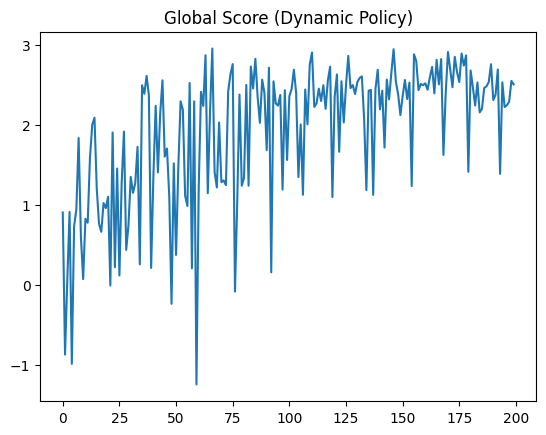

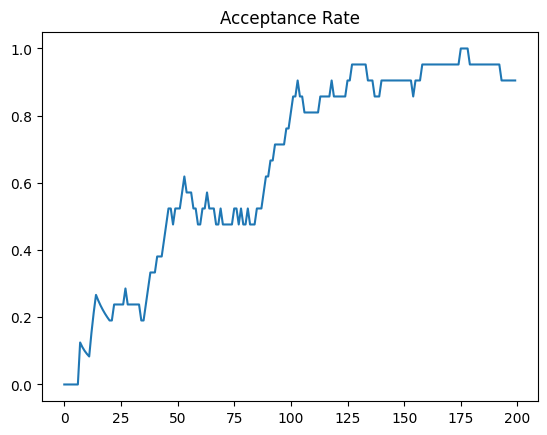

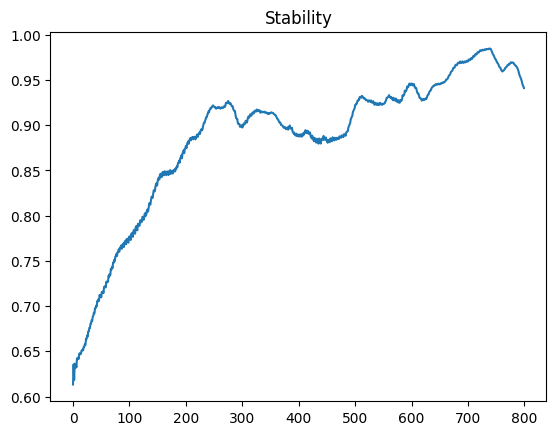

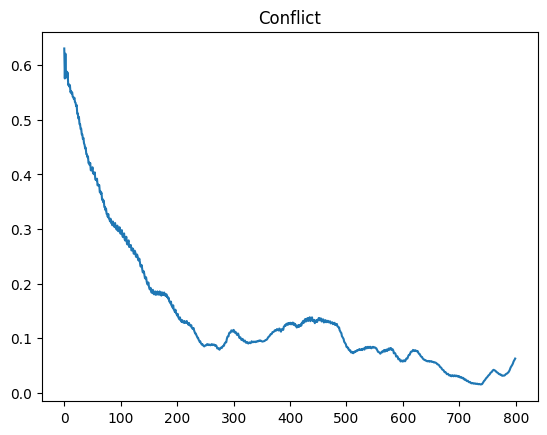

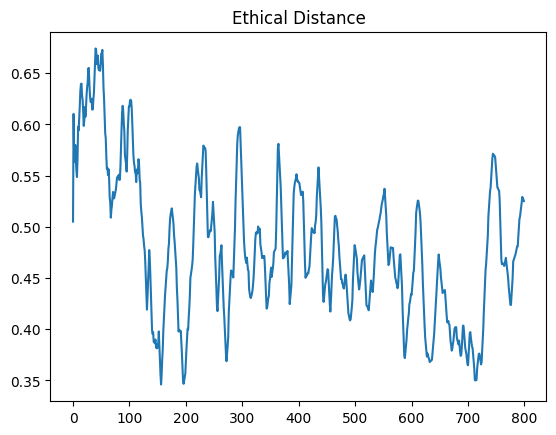

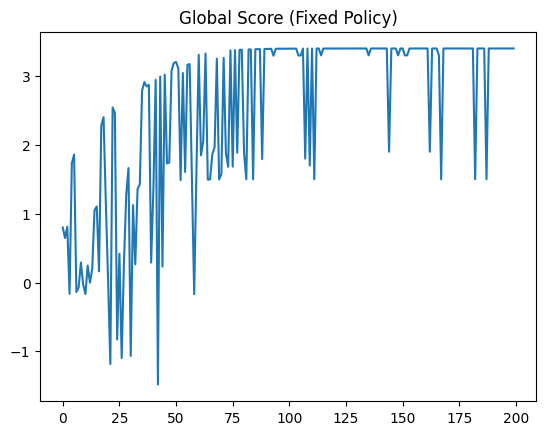

In [ ]:
def smooth(data, w=20):
    return [np.mean(data[max(0,i-w):i+1]) for i in range(len(data))]

# 1 Global Score Dynamic
plt.plot(res_dyn)
plt.title("Global Score (Dynamic Policy)")
plt.show()

# 2 Acceptance
plt.plot(smooth(acc_dyn))
plt.title("Acceptance Rate")
plt.show()

# 3 Stability
plt.plot(smooth(stab_dyn))
plt.title("Stability")
plt.show()

# 4 Conflict
plt.plot(smooth(conf_dyn))
plt.title("Conflict")
plt.show()

# 5 Distance
plt.plot(smooth(dist_dyn))
plt.title("Ethical Distance")
plt.show()

# 6 Fixed Policy Comparison
plt.plot(res_fix)
plt.title("Global Score (Fixed Policy)")
plt.show()

In [ ]:
!pip install numpy matplotlib torch

In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        # Initialize parent class (nn.Module)
        super().__init__()

        # -------- Neural Network Architecture --------
        # This is a feedforward neural network (MLP)
        # used to approximate the Q-function: Q(s, a)

        self.net = nn.Sequential(
            # Input layer:
            # Takes state vector of size = input_dim
            # Outputs 64 hidden features
            nn.Linear(input_dim, 64),

            # Activation:
            # Adds non-linearity so model can learn complex relationships
            nn.ReLU(),

            # Hidden layer:
            # Further transforms features (64 → 64)
            nn.Linear(64, 64),
            nn.ReLU(),

            # Output layer:
            # Produces Q-values for each action
            # output_dim = number of actions
            # No activation → Q-values can be any real number
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        # -------- Forward Pass --------
        # Input: state vector x
        # Output: Q-values for all possible actions

        return self.net(x)

In [ ]:
class DQNAgent:
    def __init__(self, s_dim,a_dim):
        # -------- Networks --------
        # Main network → learns Q(s, a)
        self.model = DQN(s_dim, a_dim)

        # Target network → stabilizes training
        self.target = DQN(s_dim, a_dim)

        # Initialize target with same weights
        self.target.load_state_dict(self.model.state_dict())

        # -------- Optimizer --------
        # Adam optimizer for updating model weights
        self.opt = optim.Adam(self.model.parameters(), lr=0.001)

        # -------- Replay Buffer --------
        # Stores past experiences
        self.mem = ReplayBuffer()

        # -------- Hyperparameters --------
        self.gamma = 0.95        # Discount factor
        self.eps = 1.0           # Exploration rate (start random)
        self.eps_decay = 0.995   # Decay rate
        self.eps_min = 0.05      # Minimum exploration

        # Number of actions
        self.a_dim = a_dim

    def act(self, s):
        # -------- Action Selection (Epsilon-Greedy) --------

        # Explore: random action
        if random.random() < self.eps:
            return random.randint(0, self.a_dim-1)

        # Exploit: choose best action from model
        s = torch.FloatTensor(s)

        # Return action with highest Q-value
        return torch.argmax(self.model(s)).item()

    def train(self, b=32):
        # Do not train if not enough samples
        if len(self.mem) < b: return

        # -------- Sample batch --------
        s, a, r, ns = self.mem.sample(b)

        # Convert to tensors
        s = torch.FloatTensor(s)
        ns = torch.FloatTensor(ns)
        r = torch.FloatTensor(r)
        a = torch.LongTensor(a)

        # -------- Compute Q-values --------
        q = self.model(s)        # Q(s, a)
        nq = self.target(ns)     # Q(s', a')

        # Select Q(s,a) for taken actions
        qv = q.gather(1, a.unsqueeze(1)).squeeze()

        # Max Q(s',a') for next states
        nqv = torch.max(nq, dim=1)[0]

        # -------- Bellman Target --------
        # target = r + gamma * max Q(s', a')
        target = r + self.gamma * nqv

        # -------- Loss --------
        # MSE between predicted and target Q-values
        loss = nn.MSELoss()(qv, target.detach())

        # -------- Backpropagation --------
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # -------- Epsilon Decay --------
        # Reduce exploration gradually
        if self.eps > self.eps_min:
            self.eps *= self.eps_decay

    def update(self):
        # -------- Target Network Update --------
        # Copy weights from main model → target model
        self.target.load_state_dict(self.model.state_dict())

In [ ]:
class Country:
    def __init__(self,name,power):
        # -------- Basic attributes --------

        # Country name (identifier)
        self.name = name

        # Power → influence in global decision-making
        # Higher value = more impact
        self.power = power

        # -------- Stakeholder preference vectors --------
        # Each is a 3D vector representing priorities

        self.gov = np.random.rand(3)      # Government preferences
        self.company = np.random.rand(3)  # Company (economic) preferences
        self.ngo = np.random.rand(3)      # NGO (social/environmental) preferences


def dist(a,b):
    # -------- Distance Function --------
    # Computes Euclidean distance between two vectors
    # Measures how different two vectors are
    return np.linalg.norm(a-b)


def evaluate(c,P):
    # -------- Step 1: Satisfaction --------
    # Compute average satisfaction of all stakeholders
    # Using: satisfaction = 1 - distance

    s = (
        1 - dist(c.gov, P) +      # Government satisfaction
        1 - dist(c.company, P) +  # Company satisfaction
        1 - dist(c.ngo, P)        # NGO satisfaction
    ) / 3                        # Average satisfaction

    # -------- Step 2: Conflict --------
    # Measure disagreement between stakeholders

    d1 = dist(c.gov, c.company)   # Gov vs Company
    d2 = dist(c.gov, c.ngo)       # Gov vs NGO
    d3 = dist(c.company, c.ngo)   # Company vs NGO

    # Average internal conflict
    conflict = (d1 + d2 + d3) / 3

    # -------- Step 3: Stability --------
    # Convert conflict into stability score
    # Higher conflict → lower stability

    stability = 1 / (1 + conflict)

    # -------- Step 4: Final Index --------
    # Combine satisfaction and stability

    I = 0.6 * s + 0.4 * stability

    # Return:
    # I → overall country score
    # stability → internal alignment
    # conflict → internal disagreement
    return I, stability, conflict

In [ ]:
def init():
    # -------- Initialize Countries --------
    # Create a list of countries with different power levels
    # Each country internally initializes:
    # - gov (government preferences)
    # - company (economic preferences)
    # - ngo (social/environmental preferences)

    countries = [
        Country("A", 0.9),  # High influence
        Country("B", 0.7),  # Medium influence
        Country("C", 0.8),  # Strong influence
        Country("D", 0.6)   # Lower influence
    ]

    # -------- Initialize Agents --------
    # Returning 4 agents:
    # 1. Government agent
    # 2. Company agent
    # 3. NGO agent
    # 4. Country-level agent

    # DQNAgent(6,3):
    # Input → [policy (3) + stakeholder vector (3)]
    # Output → 3 actions (accept, reject, adjust)

    # DQNAgent(2,3):
    # Input → [country score, power]
    # Output → 3 actions (accept, reject, adjust)

    return countries, \
           DQNAgent(6,3), \
           DQNAgent(6,3), \
           DQNAgent(6,3), \
           DQNAgent(2,3)

In [ ]:
policies = {
    # -------- Fairness-Oriented Policy --------
    # High weight on first dimension (e.g., social welfare / equity)
    # Low emphasis on profit and other factors
    "fair": [0.8, 0.1, 0.1],

    # -------- Profit-Oriented Policy --------
    # High weight on second dimension (e.g., economy / business growth)
    # Lower focus on fairness and other aspects
    "profit": [0.2, 0.7, 0.1],

    # -------- Balanced Policy --------
    # Equal importance to all three dimensions
    # Represents neutral / compromise policy
    "balanced": [0.33, 0.33, 0.33]
}

In [ ]:
print("\nPolicy Comparison:")
# Prints a heading for clarity in output

print("Fair:", np.mean(fair[0]))
# fair[0] → results (global scores over episodes) from "fair" policy simulation
# np.mean(...) → average performance across all episodes

print("Profit:", np.mean(profit[0]))
# profit[0] → results from "profit-oriented" policy
# Mean gives overall effectiveness of this policy

print("Balanced:", np.mean(balanced[0]))
# balanced[0] → results from "balanced" policy
# Average score shows how well compromise performs


Policy Comparison:
Fair: 4.63892430927525
Profit: 4.567766884442001
Balanced: 4.598272667704979


In [ ]:
def run(policy_type="dynamic"):

    # -------- Initialize system --------
    # countries → list of Country objects
    # gov, comp, ngo → stakeholder agents
    # c_agent → country-level agent
    countries, gov, comp, ngo, c_agent = init()

    # -------- Tracking metrics --------
    res = []         # global score per episode
    acc = []         # acceptance (1/0)
    stab = []        # stability history
    conf = []        # conflict history
    dist_hist = []   # distance from policy
    power_hist = []  # evolving power of countries

    # -------- Main loop --------
    for ep in range(200):

        # -------- Policy selection --------
        if policy_type == "dynamic":
            # Random policy each episode
            P = np.random.rand(3)
        else:
            # Fixed predefined policy
            P = np.array(policies[policy_type])

        # -------- Noise injection --------
        # Adds randomness → simulates uncertainty in real-world policies
        P = P + np.random.normal(0, 0.05, 3)

        scores = []   # country scores (I)
        actions = []  # country-level actions

        # -------- Country loop --------
        for c in countries:

            # -------- COMMUNICATION PHASE --------
            # Internal stakeholders partially align with each other
            avg = (c.gov + c.company + c.ngo) / 3

            # Each stakeholder moves slightly toward average (consensus building)
            c.gov = 0.8 * c.gov + 0.2 * avg
            c.company = 0.8 * c.company + 0.2 * avg
            c.ngo = 0.8 * c.ngo + 0.2 * avg

            # -------- Sub-agent decisions --------
            for t in ["gov", "company", "ngo"]:
                E = getattr(c, t)  # stakeholder vector

                # State = policy + stakeholder preference
                s = np.concatenate([P, E])

                # Select correct agent
                ag = gov if t == "gov" else comp if t == "company" else ngo

                # Choose action
                a = ag.act(s)

                # -------- Action effect --------
                if a == 2:
                    # Adjust → move toward policy
                    E = E + 0.1 * (P - E)

                # Update stakeholder vector
                setattr(c, t, E)

                # -------- Learning --------
                # Reward = negative distance (closer = better)
                ag.mem.push(s, a, -dist(E, P), np.concatenate([P, E]))
                ag.train()

            # -------- Country evaluation --------
            I, stability, conflict = evaluate(c, P)

            scores.append(I)

            # Store metrics
            stab.append(stability)
            conf.append(conflict)

            # Average distance from policy
            dist_hist.append(
                (dist(c.gov, P) + dist(c.company, P) + dist(c.ngo, P)) / 3
            )

        # -------- Global decision aggregation --------
        total = 0

        for i, c in enumerate(countries):
            # State = [country score, power]
            s = np.array([scores[i], c.power])

            # Country chooses action
            a = c_agent.act(s)
            actions.append(a)

            # Action impact
            if a == 0:
                total += c.power * scores[i]       # accept
            elif a == 1:
                total -= c.power * scores[i]       # reject
            else:
                total += c.power * scores[i] + 0.1 # adjust + bonus

        # -------- Acceptance decision --------
        accepted = total > 1.5

        acc.append(1 if accepted else 0)
        res.append(total)

        # -------- POWER SHIFT 🔥 --------
        # Countries gain/lose influence based on performance
        for i, c in enumerate(countries):
            c.power += 0.01 * scores[i]     # reward good performance
            c.power = np.clip(c.power, 0.5, 1.5)  # keep within bounds

            power_hist.append(c.power)

        # -------- Train country-level agent --------
        for i, c in enumerate(countries):
            s = np.array([scores[i], c.power])

            # Reward depends on global outcome
            r = total if accepted else -1

            c_agent.mem.push(s, actions[i], r, s)
            c_agent.train()

        # -------- Target network updates --------
        if ep % 10 == 0:
            gov.update()
            comp.update()
            ngo.update()
            c_agent.update()

    # -------- Return all metrics --------
    return res, acc, stab, conf, dist_hist, power_hist

In [ ]:
# -------- Run simulations for different policy types --------

dyn = run("dynamic")
# Dynamic policy → policy changes every episode (random + noise)
# Tests adaptability of agents in changing environments

fair = run("fair")
# Fair policy → predefined vector (e.g., social welfare focused)
# Tests how system behaves under fairness-oriented decisions

profit = run("profit")
# Profit policy → economy-focused policy
# Tests performance when economic priorities dominate

balanced = run("balanced")
# Balanced policy → equal weight to all dimensions
# Tests compromise scenario across all objectives

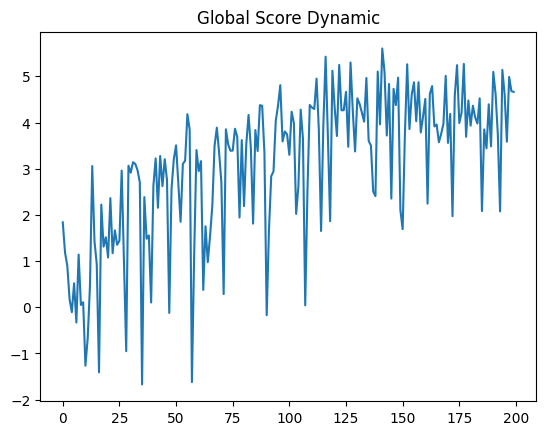

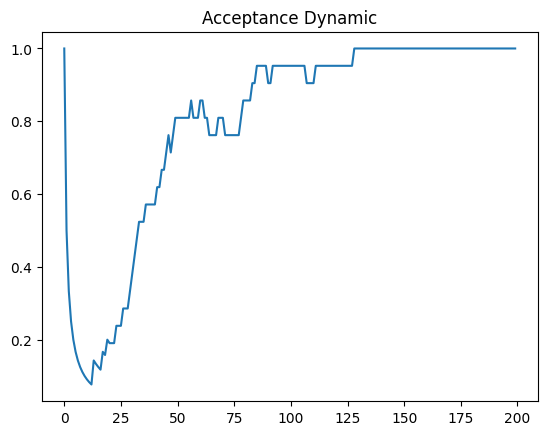

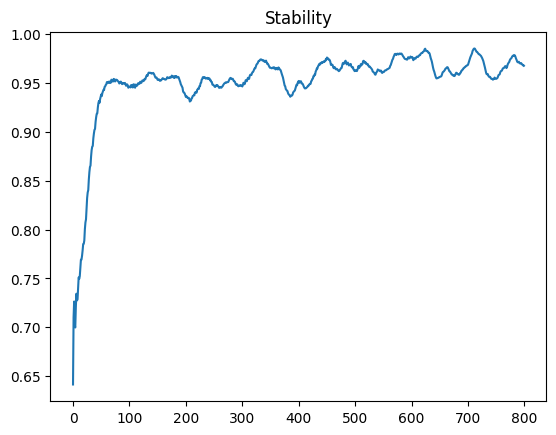

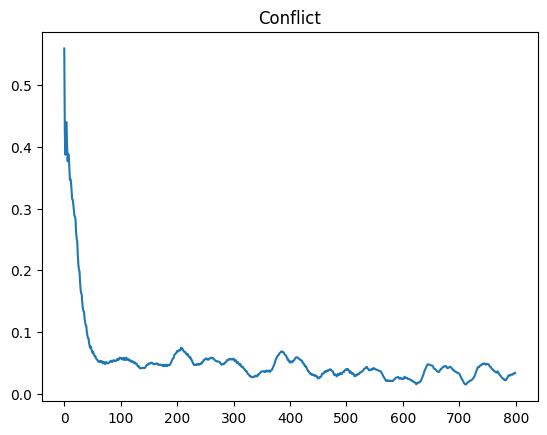

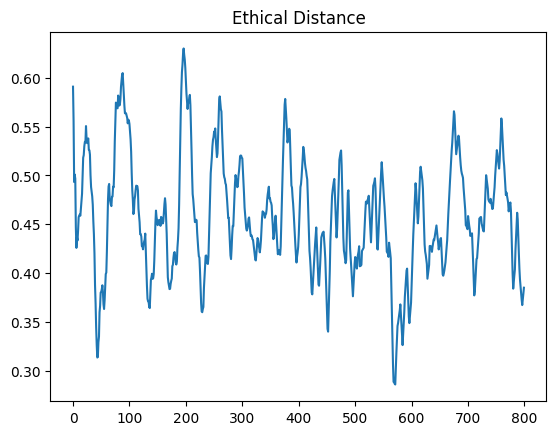

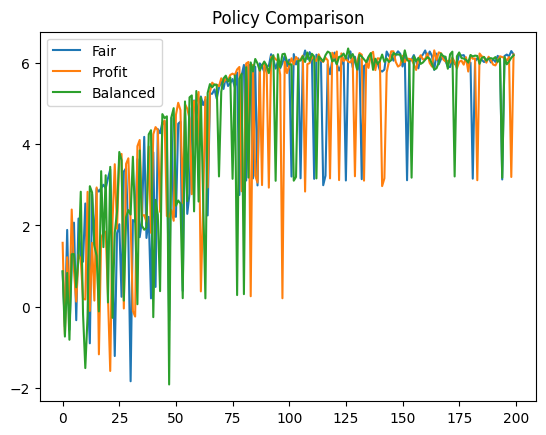

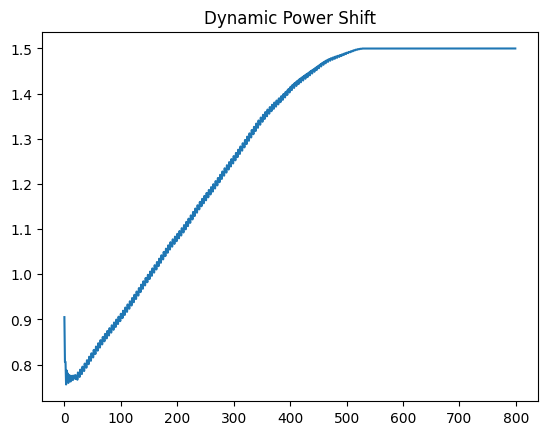

In [ ]:
def smooth(d,w=20):
    return [np.mean(d[max(0,i-w):i+1]) for i in range(len(d))]

# Dynamic
plt.plot(dyn[0]);plt.title("Global Score Dynamic");plt.show()
plt.plot(smooth(dyn[1]));plt.title("Acceptance Dynamic");plt.show()
plt.plot(smooth(dyn[2]));plt.title("Stability");plt.show()
plt.plot(smooth(dyn[3]));plt.title("Conflict");plt.show()
plt.plot(smooth(dyn[4]));plt.title("Ethical Distance");plt.show()

# Policy Comparison
plt.plot(fair[0],label="Fair")
plt.plot(profit[0],label="Profit")
plt.plot(balanced[0],label="Balanced")
plt.legend();plt.title("Policy Comparison");plt.show()

# Power Evolution
plt.plot(smooth(dyn[5]))
plt.title("Dynamic Power Shift")
plt.show()

In [ ]:
print("=== FINAL METRICS ===")

print("Avg Stability:", np.mean(stab_dyn))
print("Avg Conflict:", np.mean(conf_dyn))
print("Avg Acceptance:", np.mean(acc_dyn))
print("Avg Ethical Distance:", np.mean(dist_dyn))

=== FINAL METRICS ===
Avg Stability: 0.8894152112156355
Avg Conflict: 0.13519376887215137
Avg Acceptance: 0.695
Avg Ethical Distance: 0.47857400954073287


In [ ]:
def convergence_point(data, threshold=0.01):
    # -------- Convergence Detection Function --------
    # Finds the episode where the system stabilizes

    # data → typically global score over episodes (e.g., dyn[0])
    # threshold → how small the variation must be to consider "stable"

    for i in range(50, len(data)):
        # Check last 50 episodes
        # np.std(...) → measures variation (standard deviation)

        # If variation is very small → system has stabilized
        if np.std(data[i-50:i]) < threshold:
            return i  # return episode index where convergence starts

    # If no stable region found
    return -1


print("Convergence Episode:", convergence_point(dyn[0]))
# dyn[0] → global score over time for dynamic policy
# Prints the episode where learning stabilizes

Convergence Episode: -1
